In [5]:
import pandas as pd
df = pd.read_csv("weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [6]:
df.drop(['Weight'],axis = 1, inplace = True)
df.head()

,Gender,Height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


In [10]:
df.shape

(10000, 2)

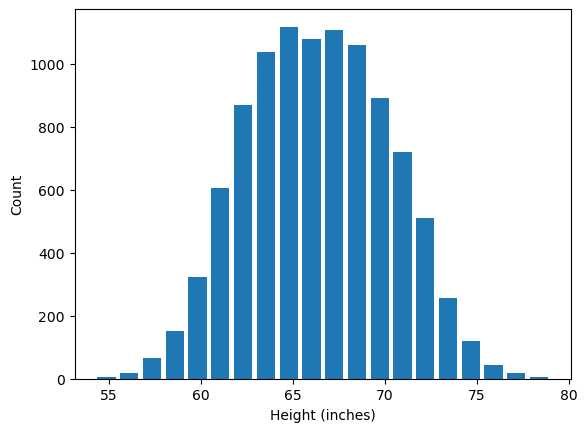

In [8]:
import matplotlib.pyplot as plt
plt.hist(df.Height, bins = 20, rwidth = 0.8)
plt.xlabel("Height (inches)")
plt.ylabel('Count')
plt.show()

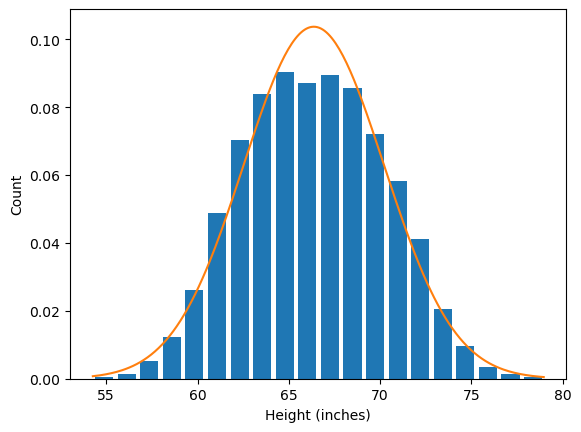

In [14]:
from scipy.stats import norm
import numpy as np

plt.hist(df.Height, bins = 20, rwidth = 0.8, density = True)
plt.xlabel("Height (inches)")
plt.ylabel('Count')


rng = np.arange(df.Height.min() , df.Height.max() , 0.1 )
plt.plot(rng, norm.pdf(rng,df.Height.mean(),df.Height.std()))

In [15]:
df.Height.describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

# 1. Outlier detection and removal using 3 Standard Deviations

In [17]:
upper_limit = df.Height.mean() + 3*df.Height.std()
upper_limit

np.float64(77.91014411714094)

In [18]:
lower_limit = df.Height.mean() - 3*df.Height.std()
lower_limit

np.float64(54.82497539250154)

In [20]:
df[(df.Height > upper_limit) | (df.Height < lower_limit)]

,Gender,Height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


In [23]:
df1 = df[(df.Height < upper_limit) & (df.Height > lower_limit)]
df1

,Gender,Height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796
...,...,...
9995,Female,66.172652
9996,Female,67.067155
9997,Female,63.867992
9998,Female,69.034243


In [24]:
df1.shape

(9993, 2)

In [26]:
df.shape[0] - df1.shape[0]

7

#### 7 outliers removed

# 2. Outlier detection and removal using Z score

### Z score is a way to achieve same thing that we did above in part(1)

### Z score indicates how many standard deviation away a data point is.

For example in our case mean is 66.37 and standard deviation is 3.84.

If a value of a data point is 77.91 then Z score for that is 3 because it is 3 standard deviation away (77.91 = 66.37 + 3*3.84)

Z-Score Formula
The statistical formula for a value's z-score is calculated using the following formula:

z = ( x - μ ) / σ
Where:

z = z-score
x = the value being evaluated
μ = the mean
σ = the standard deviation

z = (77.91 - 66.37 ) / 3.84

z = 3

In [31]:
(77.91 - 66.37 ) / 3.84

3.0052083333333313

In [34]:
df["zscore"] = (df.Height - df.Height.mean()) / df.Height.std()

In [35]:
df

,Gender,Height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375
...,...,...,...
9995,Female,66.172652,-0.050658
9996,Female,67.067155,0.181830
9997,Female,63.867992,-0.649655
9998,Female,69.034243,0.693090


## Now we can filter out the values above 3 stds which we did above

In [36]:
df[df['zscore']>3]

,Gender,Height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [37]:
df[df['zscore']<-3]

,Gender,Height,zscore
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [39]:
df[(df['zscore']<-3) | (df['zscore']>3)]

,Gender,Height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [40]:
df_no_outliers = df[(df['zscore']<3) & (df['zscore']>-3)]
df_no_outliers

,Gender,Height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375
...,...,...,...
9995,Female,66.172652,-0.050658
9996,Female,67.067155,0.181830
9997,Female,63.867992,-0.649655
9998,Female,69.034243,0.693090
